<a href="https://colab.research.google.com/github/CaioVM47/Financial-Data-Analysis/blob/main/Financial-Data-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Sales Analysis

## Objetivo

Este projeto tem como objetivo analisar dados globais de vendas a partir da integração de três conjuntos de dados: eventos de vendas, países e categorias de produtos.

A análise contempla o processo completo de preparação e exploração dos dados, incluindo:

- avaliação da qualidade dos dados;
- tratamento de valores ausentes e inconsistências;
- validação e integração entre diferentes fontes;
- criação de métricas financeiras e operacionais;
- análise de vendas por produto, geografia e canal;
- avaliação do tempo entre pedido e envio;
- investigação da relação entre tempo de envio e lucro;
- análise da evolução das vendas ao longo do tempo;
- identificação de possíveis padrões semanais de vendas.

O objetivo final é transformar os dados disponíveis em indicadores e insights que apoiem a compreensão do desempenho comercial.

## 1. Setup e Carregamento dos Dados

Nesta etapa são importadas as bibliotecas utilizadas na análise e carregados os três conjuntos de dados:

- `events`: registros das vendas e pedidos;
- `countries`: informações geográficas dos países;
- `products`: identificação das categorias de produtos.

Durante a leitura da base de países, o tratamento padrão de valores ausentes do Pandas foi ajustado para preservar códigos válidos como `"NA"`, utilizado pela Namíbia no padrão ISO alpha-2.

In [ ]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator, AutoMinorLocator
drive.mount('/content/drive')
countries = pd.read_csv('/content/drive/MyDrive/countries.csv', keep_default_na=False, na_values=['']) #Corrige valor ausente no index 8 pois o alpha-2 de Namibia é NA
events = pd.read_csv('/content/drive/MyDrive/events.csv')
products = pd.read_csv('/content/drive/MyDrive/products.csv')
plt.style.use('dark_background')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#@title Criando método compactador para os gráficos
def compact_number(x, pos):
    if abs(x) >= 1_000_000_000:
        value, suffix = x / 1_000_000_000, 'B'
    elif abs(x) >= 1_000_000:
        value, suffix = x / 1_000_000, 'M'
    elif abs(x) >= 1_000:
        value, suffix = x / 1_000, 'K'
    else:
        return f'{x:.0f}'

    return f'{value:g}{suffix}'

## 2. Visão Geral dos Dados

Antes de iniciar o processo de limpeza e transformação, foi realizada uma exploração inicial dos três conjuntos de dados para compreender sua estrutura e identificar possíveis problemas de qualidade.

Nesta etapa são avaliados:

- quantidade de linhas e colunas;
- primeiras observações de cada conjunto;
- tipos das variáveis;
- estatísticas descritivas;
- quantidade e proporção de valores ausentes;
- presença de registros duplicados.

Essa análise inicial orienta as decisões de limpeza e preparação realizadas nas etapas seguintes.

In [ ]:
for name, data in {'COUNTRIES' : countries, 'PRODUCTS' : products, 'EVENTS' : events}.items():
  print(f'\n{"=" * 40}')
  print(name)
  print(f'{"=" * 40}')
  print('\nHead:')
  print(data.head())
  print('\nDescribe:')
  print(data.describe())
  print('\nShape:')
  print(data.shape)
  print('\nTipos:')
  print(data.dtypes)
  print('\nValores ausentes:')
  print(data.isna().sum())
  print('\nPercentual de valores ausentes:')
  print((data.isna().mean() * 100).round(2))
  print('\nDuplicatas exatas:')
  print(data.duplicated().sum())


COUNTRIES

Head:
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia

Describe:
               name alpha-2 alpha-3  region          sub-region
count           249     249     249     248                 248
unique          249     249     249       5                  17
top     Afghanistan      AF     AFG  Africa  Sub-Saharan Africa
freq              1       1       1      60                  53

Shape:
(249, 5)

Tipos:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object

Valores ausentes:
name          0
alpha-2       0
alpha-3       0
region        1
sub-region    1
dtype: int64

Percentual de valores ausentes:
na

## 3. Qualidade e Limpeza dos Dados

Após a exploração inicial, foram realizadas validações para identificar problemas que poderiam comprometer as análises posteriores.

A etapa de qualidade dos dados inclui:

- investigação dos valores ausentes e definição de estratégias de tratamento;
- validação da unicidade das chaves principais;
- verificação da integridade referencial entre as tabelas;
- conversão e validação das colunas de data;
- identificação de registros duplicados e inconsistências textuais;
- verificação de possíveis anomalias nos dados;
- criação de uma base limpa para as análises seguintes.

As decisões de limpeza foram tomadas buscando preservar o máximo possível das informações originais e evitar imputações sem justificativa.

### 3.1 Valores Ausentes

In [ ]:
for name, data in {'COUNTRIES' : countries, 'PRODUCTS' : products, 'EVENTS' : events}.items():
  print(f'\n{"=" * 40}')
  print(name)
  print(f'{"=" * 40}')
  print('\nValores Ausentes (Detalhado):')
  print(data[data.isna().any(axis=1)])


COUNTRIES

Valores Ausentes (Detalhado):
         name alpha-2 alpha-3 region sub-region
8  Antarctica      AQ     ATA    NaN        NaN

PRODUCTS

Valores Ausentes (Detalhado):
Empty DataFrame
Columns: [id, item_type]
Index: []

EVENTS

Valores Ausentes (Detalhado):
       Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
2     101025998  7/18/2014  8/11/2014              M          NaN        7940   
13    104548490   1/1/2014   1/5/2014              M          NaN        7331   
26    117929494  1/24/2015   3/2/2015              H          NaN        4594   
29    118859469   6/2/2011   7/1/2011              L          NaN        8969   
43    126948583  5/24/2017   7/9/2017              C          NaN        7331   
...         ...        ...        ...            ...          ...         ...   
1213  919922006  8/27/2011  9/18/2011              L          NaN        4594   
1220  922564303  3/17/2017   4/2/2017              L          NaN        7940   
12

### 3.2 Decisões de Tratamento dos Valores Ausentes

Após a investigação dos valores ausentes, foram adotadas estratégias diferentes de acordo com o contexto de cada variável.

- **Countries:** os valores ausentes de `region` e `sub-region` associados à Antarctica foram mantidos, pois não há informação suficiente no conjunto de dados para realizar uma imputação fundamentada. Como o código `alpha-3` está presente, essa ausência não compromete a integração entre as tabelas.

- **Events — Country Code:** os 82 registros sem código de país foram preservados. Após a integração das tabelas, esses registros serão classificados como `Unknown`, permitindo que continuem participando das análises que não dependem de localização geográfica.

- **Events — Units Sold:** os 2 registros sem quantidade vendida foram removidos da base analítica. Como `Units Sold` é necessária para calcular receita, custo e lucro, realizar uma imputação introduziria valores artificiais. Esses registros representam aproximadamente 0,15% da base.

### 3.3 Validação de Chaves e Integridade Referencial

Antes de realizar a integração entre os conjuntos de dados, foram validadas as chaves utilizadas nos relacionamentos.

Foram verificadas:

- unicidade de `Order ID` na base de eventos;
- unicidade de `alpha-3` na base de países;
- unicidade de `id` na base de produtos;
- existência dos códigos de país presentes em `events` na tabela `countries`;
- existência dos identificadores de produto presentes em `events` na tabela `products`.

Essa validação permite identificar possíveis problemas de cardinalidade ou registros sem correspondência antes da realização dos `merge`.

In [ ]:
print("Country alpha-3 único:")
print(countries['alpha-3'].is_unique)

print("\nProduct ID único:")
print(products['id'].is_unique)

print("\nOrder ID único:")
print(events['Order ID'].is_unique)

Country alpha-3 único:
True

Product ID único:
True

Order ID único:
True


In [ ]:
#@title Verificando se todos os códigos de país não nulos existentes em events possuem correspondência em countries, e todos os produtos possuem correspondência em products.
invalid_countries = events.loc[events['Country Code'].notna() & ~events['Country Code'].isin(countries['alpha-3']), 'Country Code'].unique()

invalid_products = events.loc[~events['Product ID'].isin(products['id']), 'Product ID'].unique()

print("Country Codes sem correspondência:")
print(invalid_countries)

print("\nProduct IDs sem correspondência:")
print(invalid_products)

Country Codes sem correspondência:
[]

Product IDs sem correspondência:
[]


### 3.4 Construção da Base Limpa

Com base nas decisões tomadas nas etapas anteriores, foi criada uma cópia da base de eventos para aplicação das transformações necessárias sem alterar os dados originais.

Nesta etapa são realizados:

- remoção dos registros sem `Units Sold`;
- conversão de `Units Sold` para inteiro;
- padronização de valores textuais;
- convertendo `Order Date` e `Ship Date` para datetime
- correção de inconsistências em `Order Priority` e `Sales Channel`.

A base resultante será utilizada nas etapas de integração e análise.

In [ ]:
#@title Criando no df limpo chamado events_clean, removendo as 2 linhas sem Units Sold e transformando Units Sold em int
events_clean = events.copy()
events_clean = events_clean.dropna(subset=['Units Sold'])
events_clean['Order Date'] = pd.to_datetime(events_clean['Order Date'])
events_clean['Ship Date'] = pd.to_datetime(events_clean['Ship Date'])
print(f"{events_clean['Units Sold'].isna().sum()} <- Deve ser 0 (count de valores nulos)")
events_clean['Units Sold'] = events_clean['Units Sold'].astype(int)
print(f"{events_clean['Units Sold'].dtype} <- Deve ser int64")

0 <- Deve ser 0 (count de valores nulos)
int64 <- Deve ser int64


### 3.5 Padronização e Consistência de Dados Textuais

In [ ]:
for name, data in {'COUNTRIES' : countries, 'PRODUCTS' : products, 'EVENTS' : events_clean}.items():

    print(f'\n{"=" * 40}')
    print(name)
    print(f'{"=" * 40}')

    text_columns = data.select_dtypes(include='object').columns

    for column in text_columns:

        original = data[column].dropna()

        normalized = (
            original
            .str.strip()
            .str.lower()
        )

        before = original.nunique()
        after = normalized.nunique()

        print(f'\n{column}')
        print(f'Únicos antes: {before}')
        print(f'Únicos depois: {after}')

        if before != after:
            print('Possível inconsistência')
            print(f"Original: {original.unique()}")
            print(f"Normalizado: {normalized.unique()}")


COUNTRIES

name
Únicos antes: 249
Únicos depois: 249

alpha-2
Únicos antes: 249
Únicos depois: 249

alpha-3
Únicos antes: 249
Únicos depois: 249

region
Únicos antes: 5
Únicos depois: 5

sub-region
Únicos antes: 17
Únicos depois: 17

PRODUCTS

item_type
Únicos antes: 12
Únicos depois: 12

EVENTS

Order Priority
Únicos antes: 6
Únicos depois: 4
Possível inconsistência
Original: ['M' 'C' 'L' 'H' ' C' 'M ']
Normalizado: ['m' 'c' 'l' 'h']

Country Code
Únicos antes: 45
Únicos depois: 45

Sales Channel
Únicos antes: 3
Únicos depois: 2
Possível inconsistência
Original: ['Online' 'Offline' 'online']
Normalizado: ['online' 'offline']


####Foram identificadas inconsistências textuais nas colunas Order Priority e Sales Channel. Em Order Priority, havia espaços extras em alguns valores; em Sales Channel, a categoria Online aparecia com diferenças de capitalização. Os valores foram padronizados para evitar categorias duplicadas durante as análises.

In [ ]:
#@title Corrigindo duplicatas verificadas
events_clean['Order Priority'] = (
    events_clean['Order Priority']
    .str.strip()
)

events_clean['Sales Channel'] = (
    events_clean['Sales Channel']
    .str.strip()
    .str.title()
)

#Verificando
print(events_clean['Order Priority'].unique())
print(events_clean['Sales Channel'].unique())

['M' 'C' 'L' 'H']
['Online' 'Offline']


### 3.7 Validação de Anomalias

Além dos valores ausentes e inconsistências de formato, foram realizadas verificações para identificar valores numericamente ou logicamente incompatíveis com o contexto das vendas.

Foram avaliados:

- quantidade vendida menor ou igual a zero;
- preço unitário menor ou igual a zero;
- custo unitário menor ou igual a zero;
- custo unitário superior ao preço de venda;
- datas de envio anteriores às datas dos pedidos.

Essas validações ajudam a evitar que registros anômalos distorçam os indicadores financeiros e operacionais calculados posteriormente.

In [ ]:
# Verificação de possíveis anomalias

print('Units Sold <= 0:')
display(events_clean[events_clean['Units Sold'] <= 0])

print('\nUnit Price <= 0:')
display(events_clean[events_clean['Unit Price'] <= 0])

print('\nUnit Cost <= 0:')
display(events_clean[events_clean['Unit Cost'] <= 0])

print('\nUnit Cost > Unit Price:')
display(events_clean[events_clean['Unit Cost'] > events_clean['Unit Price']])

print('\nShip Date < Order Date:')
display(events_clean[events_clean['Ship Date'] < events_clean['Order Date']])

Units Sold <= 0:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost



Unit Price <= 0:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost



Unit Cost <= 0:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost



Unit Cost > Unit Price:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost



Ship Date < Order Date:


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


Nenhuma anomalia adicional foi identificada nas regras de validação aplicadas.

## 4. Integração e Preparação da Base Analítica

Após a limpeza e validação dos dados, as três bases foram integradas para formar um único DataFrame analítico.

A integração foi realizada a partir das seguintes chaves:

- `events.Country Code` → `countries.alpha-3`
- `events.Product ID` → `products.id`

Os `merge` foram validados com cardinalidade `many_to_one`, garantindo que múltiplos eventos possam se relacionar a um único país ou produto sem introduzir duplicações inesperadas.

Os registros sem identificação geográfica foram preservados e classificados como `Unknown`, permitindo que continuem participando das análises que não dependem diretamente de país ou região.

In [ ]:
#@title fazendo um left join da tabela events e countries e da nova df com a tabela products
# Merge com países
df = events_clean.merge(
    countries,
    how='left',
    left_on='Country Code',
    right_on='alpha-3',
    validate='many_to_one'
)

# Merge com produtos
df = df.merge(
    products,
    how='left',
    left_on='Product ID',
    right_on='id',
    validate='many_to_one'
)

# Substituindo os nulos nesse novo df por Unknown
df['Country Code'] = df['Country Code'].fillna('Unknown')

df[['name', 'region', 'sub-region']] = (
    df[['name', 'region', 'sub-region']]
    .fillna('Unknown')
)
print('Antes:', events_clean.shape)
print('Depois:', df.shape)
print("\nUnknown por coluna:")
print(df[['Country Code', 'name', 'region', 'sub-region']].eq('Unknown').sum())
df.head()

Antes: (1328, 10)
Depois: (1328, 17)

Unknown por coluna:
Country Code    82
name            82
region          82
sub-region      82
dtype: int64


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,alpha-3,region,sub-region,id,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,Norway,NO,NOR,Europe,Northern Europe,2103,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,Serbia,RS,SRB,Europe,Southern Europe,2103,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,Unknown,NaN,NaN,Unknown,Unknown,7940,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,Montenegro,ME,MNE,Europe,Southern Europe,2455,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,Serbia,RS,SRB,Europe,Southern Europe,1270,Beverages


### 4.1 Padronização da Base Integrada

Após a integração, as colunas foram renomeadas para melhorar a legibilidade da base analítica e campos auxiliares utilizados apenas nos relacionamentos foram removidos.

In [ ]:
df = df.rename(columns={
    'name': 'Country',
    'region': 'Region',
    'sub-region': 'Subregion',
    'item_type': 'Product Category'
})

df = df.drop(columns=[
    'alpha-2',
    'alpha-3',
    'id'
])

### 4.2 Criação das Métricas Analíticas

Com a base integrada, foram criadas métricas financeiras, logísticas e temporais para suportar as análises posteriores.

As principais métricas derivadas são:

- **Revenue:** receita total de cada pedido;
- **Total Cost:** custo total associado às unidades vendidas;
- **Profit:** diferença entre receita e custo dos produtos;
- **Profit Margin:** lucro proporcional à receita;
- **Shipping Days:** intervalo em dias entre o pedido e o envio;
- **Order Day:** dia da semana em que o pedido foi realizado.
- **Order Month:** mês do pedido utilizado nas análises de evolução temporal.

In [ ]:
df['Order Month'] = (
    df['Order Date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

df['Revenue'] = df['Units Sold'] * df['Unit Price']
df['Total Cost'] = df['Units Sold'] * df['Unit Cost']
df['Profit'] = df['Revenue'] - df['Total Cost']
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order Day'] = df['Order Date'].dt.day_name()
df['Profit Margin'] = (df['Profit'] / df['Revenue']) * 100
df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,...,Region,Subregion,Product Category,Order Month,Revenue,Total Cost,Profit,Shipping Days,Order Day,Profit Margin
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650,205.70,117.11,...,Europe,Northern Europe,Cereal,2014-10-01,133705.00,76121.50,57583.50,10,Wednesday,43.067574
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993,205.70,117.11,...,Europe,Southern Europe,Cereal,2016-08-01,409960.10,233400.23,176559.87,0,Thursday,43.067574
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,...,Unknown,Unknown,Household,2014-07-01,3136191.11,2358420.22,777770.89,24,Friday,24.799856
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171,109.28,35.84,...,Europe,Southern Europe,Clothes,2017-05-01,127966.88,41968.64,85998.24,31,Saturday,67.203514
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648,47.45,31.79,...,Europe,Southern Europe,Beverages,2012-08-01,362897.60,243129.92,119767.68,38,Saturday,33.003161


## 5. Indicadores Gerais de Desempenho

Com a base analítica preparada, foram calculados indicadores gerais para fornecer uma visão consolidada do desempenho das vendas.

Os principais KPIs avaliados são:

- total de pedidos;
- receita total;
- custo total;
- lucro total;
- unidades vendidas;
- quantidade de países identificados;
- margem global de lucro.

Esses indicadores servem como referência para contextualizar as análises mais detalhadas realizadas nas próximas seções.

In [ ]:
total_orders = df['Order ID'].nunique()
total_revenue = df['Revenue'].sum()
total_cost = df['Total Cost'].sum()
total_profit = df['Profit'].sum()
total_units = df['Units Sold'].sum()
total_countries = df.loc[df['Country'] != 'Unknown', 'Country'].nunique()
global_profit_margin  = (total_profit / total_revenue) * 100
avg_order_revenue = df['Revenue'].mean()
avg_order_profit = df['Profit'].mean()


print(f'Total de pedidos: {total_orders:,}')
print(f'Receita total: ${total_revenue:,.2f}')
print(f'Custo total: ${total_cost:,.2f}')
print(f'Lucro bruto total: ${total_profit:,.2f}')
print(f'Unidades vendidas: {total_units:,}')
print(f'Países identificados: {total_countries}')
print(f'Margem de lucro geral: {global_profit_margin :.2f}%')
print(f'Receita média por pedido: ${avg_order_revenue:,.2f}')
print(f'Lucro médio por pedido: ${avg_order_profit:,.2f}')

Total de pedidos: 1,328
Receita total: $1,702,129,408.21
Custo total: $1,200,694,949.21
Lucro bruto total: $501,434,459.00
Unidades vendidas: 6,576,524
Países atendidos: 45
Margem de lucro geral: 29.46%
Receita média por pedido: $1,281,723.95
Lucro médio por pedido: $377,586.19


### Visão Geral

A base analisada contém **1.328 pedidos**, que somam aproximadamente **US$ 1,70 bilhão em receita** e **US$ 501,4 milhões em lucro**.

Foram comercializadas mais de **6,5 milhões de unidades** em **45 países identificados**, com margem global de lucro de aproximadamente **29,46%**.

Os registros sem identificação geográfica foram preservados na base, portanto a cobertura real pode incluir países adicionais não identificados.

#Análise dos KPIs

####Após o processo de limpeza, foram analisados 1.328 pedidos, totalizando aproximadamente US 1,70 bilhão em receita e US 1,20 bilhão em custos de produtos. O lucro calculado foi de aproximadamente US 501,4 milhões, correspondendo a uma margem global de 29,46%. Ao todo, foram vendidas mais de 6,57 milhões de unidades, distribuídas entre 45 países identificados.

## 6. Construção das Tabelas Analíticas

Para facilitar as análises e separar a etapa de preparação dos dados da etapa de visualização, foram criados DataFrames agregados para diferentes dimensões do negócio.

Essas tabelas analíticas consolidam métricas como receita, custo, lucro, unidades vendidas, quantidade de pedidos e tempo de envio, permitindo reutilizar os mesmos resultados em diferentes visualizações.

Foram criadas agregações para:

- categorias de produtos;
- países e regiões;
- canais de vendas;
- tempo de envio por produto, país e região;
- relação entre tempo de envio e lucro;
- evolução mensal das vendas;
- vendas por dia da semana.

In [ ]:
#@title Criando DataFrame agregado product_analysis
product_analysis = (
    df.groupby('Product Category', as_index=False)
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Cost=('Total Cost', 'sum'),
          Profit=('Profit', 'sum'),
          Units_Sold=('Units Sold', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Profit', ascending=False)
)

product_analysis['Profit_Margin'] = (
    product_analysis['Profit']
    / product_analysis['Revenue']
    * 100
)

product_analysis.head()

,Product Category,Revenue,Total_Cost,Profit,Units_Sold,Orders,Profit_Margin
4,Cosmetics,2.331548e+08,1.404315e+08,92723306.17,533291,114,39.768984
8,Office Supplies,4.022140e+08,3.242368e+08,77977176.25,617641,123,19.386987
6,Household,2.942052e+08,2.212427e+08,72962466.77,440249,97,24.799856
0,Baby Food,1.436476e+08,8.970659e+07,53940997.16,562706,112,37.550924
3,Clothes,6.462655e+07,2.119524e+07,43431314.40,591385,105,67.203514


In [ ]:
#@title Criando DataFrame agregado region_analysis
region_analysis = (
    df.groupby('Region', as_index=False)
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Cost=('Total Cost', 'sum'),
          Profit=('Profit', 'sum'),
          Units_Sold=('Units Sold', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Profit', ascending=False)
)

region_analysis.head()

,Region,Revenue,Total_Cost,Profit,Units_Sold,Orders
1,Europe,1.505653e+09,1.057096e+09,4.485568e+08,5761244,1164
2,Unknown,1.031456e+08,7.542022e+07,2.772542e+07,404853,82
0,Asia,9.333089e+07,6.817863e+07,2.515225e+07,410427,82


In [ ]:
#@title Criando DataFrame agregado country_analysis
country_analysis = (
    df[df['Country'] != 'Unknown']
      .groupby('Country', as_index=False)
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Cost=('Total Cost', 'sum'),
          Profit=('Profit', 'sum'),
          Units_Sold=('Units Sold', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Profit', ascending=False)
)

country_analysis.head()

,Country,Revenue,Total_Cost,Profit,Units_Sold,Orders
1,Andorra,47756693.17,32346656.54,15410036.63,185686,40
43,Ukraine,53252317.54,38447391.80,14804925.74,164577,33
27,Malta,47145320.81,32535192.93,14610127.88,173641,32
36,San Marino,47883708.48,34090715.67,13792992.81,192228,40
18,Hungary,42408249.12,28622018.09,13786231.03,152242,25


In [ ]:
#@title Criando DataFrame agregado channel_analysis
channel_analysis = (
    df.groupby('Sales Channel', as_index=False)
      .agg(
          Revenue=('Revenue', 'sum'),
          Total_Cost=('Total Cost', 'sum'),
          Profit=('Profit', 'sum'),
          Units_Sold=('Units Sold', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

channel_analysis['Profit_Margin'] = (
    channel_analysis['Profit']
    / channel_analysis['Revenue']
    * 100
)

channel_analysis.head()

,Sales Channel,Revenue,Total_Cost,Profit,Units_Sold,Orders,Profit_Margin
0,Offline,8.717606e+08,6.182941e+08,2.534665e+08,3320363,665,29.075243
1,Online,8.303688e+08,5.824008e+08,2.479679e+08,3256161,663,29.862387


In [ ]:
#@title Criando DataFrame agregado shipping_product_analysis
shipping_product_analysis = (
    df.groupby('Product Category', as_index=False)
      .agg(
          Avg_Shipping_Days=('Shipping Days', 'mean'),
          Median_Shipping_Days=('Shipping Days', 'median'),
          Min_Shipping_Days=('Shipping Days', 'min'),
          Max_Shipping_Days=('Shipping Days', 'max'),
          Orders=('Order ID', 'nunique')
      )
)

shipping_product_analysis.head()

,Product Category,Avg_Shipping_Days,Median_Shipping_Days,Min_Shipping_Days,Max_Shipping_Days,Orders
0,Baby Food,26.339286,28.5,0,50,112
1,Beverages,24.123967,23.0,0,50,121
2,Cereal,27.184466,29.0,0,50,103
3,Clothes,23.104762,21.0,0,50,105
4,Cosmetics,25.912281,28.0,0,50,114


In [ ]:
#@title Criando DataFrame agregado shipping_country_analysis
shipping_country_analysis = (
    df[df['Country'] != 'Unknown']
      .groupby('Country', as_index=False)
      .agg(
          Avg_Shipping_Days=('Shipping Days', 'mean'),
          Median_Shipping_Days=('Shipping Days', 'median'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Avg_Shipping_Days', ascending=False)
)

shipping_country_analysis.head()

,Country,Avg_Shipping_Days,Median_Shipping_Days,Orders
18,Hungary,32.640000,36.0,25
15,Georgia,29.695652,32.0,23
3,Austria,28.500000,29.0,28
38,Slovakia,28.466667,32.0,30
25,Luxembourg,27.750000,30.5,28


In [ ]:
#@title Criando DataFrame agregado shipping_region_analysis
shipping_region_analysis = (
    df.groupby('Region', as_index=False)
      .agg(
          Avg_Shipping_Days=('Shipping Days', 'mean'),
          Median_Shipping_Days=('Shipping Days', 'median'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Avg_Shipping_Days', ascending=False)
)

shipping_region_analysis.head()

,Region,Avg_Shipping_Days,Median_Shipping_Days,Orders
0,Asia,26.085366,25.5,82
1,Europe,24.790378,25.0,1164
2,Unknown,23.439024,23.5,82


In [ ]:
#@title Criando DataFrame agregado shipping_profit_analysis
shipping_profit_analysis = (
    df.groupby('Shipping Days', as_index=False)
      .agg(
          Avg_Profit=('Profit', 'mean'),
          Total_Profit=('Profit', 'sum'),
          Orders=('Order ID', 'nunique')
      )
      .sort_values('Shipping Days')
)

shipping_profit_analysis.head()

,Shipping Days,Avg_Profit,Total_Profit,Orders
0,0,348379.706000,6967594.12,20
1,1,309541.679091,6809916.94,22
2,2,339626.031154,8830276.81,26
3,3,285222.778788,9412351.70,33
4,4,300644.403548,9319976.51,31


In [ ]:
#@title Criando DataFrame agregado monthly_product_analysis
monthly_product_analysis = (
    df.groupby(
        ['Order Month', 'Product Category'],
        as_index=False
    )
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Units_Sold=('Units Sold', 'sum'),
        Orders=('Order ID', 'nunique')
    )
)

monthly_product_analysis.head()

,Order Month,Product Category,Revenue,Profit,Units_Sold,Orders
0,2010-01-01,Baby Food,4149321.12,1558108.44,16254,3
1,2010-01-01,Beverages,315352.70,104076.36,6646,2
2,2010-01-01,Cereal,4828601.80,2079561.66,23474,3
3,2010-01-01,Clothes,1100012.48,739247.04,10066,3
4,2010-01-01,Cosmetics,5452321.20,2168332.77,12471,2


In [ ]:
#@title Criando DataFrame agregado monthly_country_analysis
monthly_country_analysis = (
    df[df['Country'] != 'Unknown']
      .groupby(
          ['Order Month', 'Country'],
          as_index=False
      )
      .agg(
          Revenue=('Revenue', 'sum'),
          Profit=('Profit', 'sum'),
          Units_Sold=('Units Sold', 'sum'),
          Orders=('Order ID', 'nunique')
      )
)

monthly_country_analysis.head()

,Order Month,Country,Revenue,Profit,Units_Sold,Orders
0,2010-01-01,Andorra,1440093.59,518560.02,10303,2
1,2010-01-01,Armenia,1858575.21,772613.71,11327,3
2,2010-01-01,Belarus,1302418.80,517958.73,2979,1
3,2010-01-01,Bosnia and Herzegovina,778723.44,238771.68,9528,1
4,2010-01-01,Bulgaria,836083.62,342606.51,5427,1


In [ ]:
#@title Criando DataFrame agregado monthly_region_analysis
monthly_region_analysis = (
    df.groupby(
        ['Order Month', 'Region'],
        as_index=False
    )
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Units_Sold=('Units Sold', 'sum'),
        Orders=('Order ID', 'nunique')
    )
)

monthly_region_analysis.head()

,Order Month,Region,Revenue,Profit,Units_Sold,Orders
0,2010-01-01,Asia,2024251.93,834826.85,11976,4
1,2010-01-01,Europe,18413854.79,7455342.68,93737,15
2,2010-01-01,Unknown,677247.76,277519.48,4396,1
3,2010-02-01,Asia,4822686.48,959065.58,13399,2
4,2010-02-01,Europe,15030336.72,3347419.49,54810,10


In [ ]:
#@title Criando DataFrame agregado weekday_product_analysis
weekday_product_analysis = (
    df.groupby(
        ['Order Day', 'Product Category'],
        as_index=False
    )
    .agg(
        Revenue=('Revenue', 'sum'),
        Profit=('Profit', 'sum'),
        Units_Sold=('Units Sold', 'sum'),
        Orders=('Order ID', 'nunique')
    )
)

weekday_product_analysis.head()

,Order Day,Product Category,Revenue,Profit,Units_Sold,Orders
0,Friday,Baby Food,20200051.12,7585305.94,79129,16
1,Friday,Beverages,3202875.00,1057050.00,67500,12
2,Friday,Cereal,12884430.90,5549011.83,62637,12
3,Friday,Clothes,6696022.72,4499962.56,61274,10
4,Friday,Cosmetics,61875167.20,24607125.62,141526,28


## 7. Análise Exploratória e Visualizações

Nesta etapa, os dados agregados são utilizados para explorar o desempenho das vendas em diferentes dimensões do negócio.

As visualizações foram organizadas para responder às principais perguntas do projeto:

- quais categorias de produtos apresentam maior desempenho financeiro e volume de vendas;
- como as vendas se distribuem geograficamente entre países e regiões;
- como os resultados se comportam entre os canais Online e Offline;
- como o tempo de envio varia entre produtos, países e regiões;
- se existe relação entre o tempo de envio e o lucro;
- como as vendas evoluem ao longo do tempo;
- se existem padrões semanais de venda por categoria de produto.

### 7.1 Desempenho por Categoria de Produto

A análise por categoria considera diferentes perspectivas de desempenho, incluindo receita, lucro, margem e volume de unidades vendidas.

Essas métricas permitem distinguir categorias com maior faturamento, maior contribuição absoluta para o lucro e maior rentabilidade proporcional.

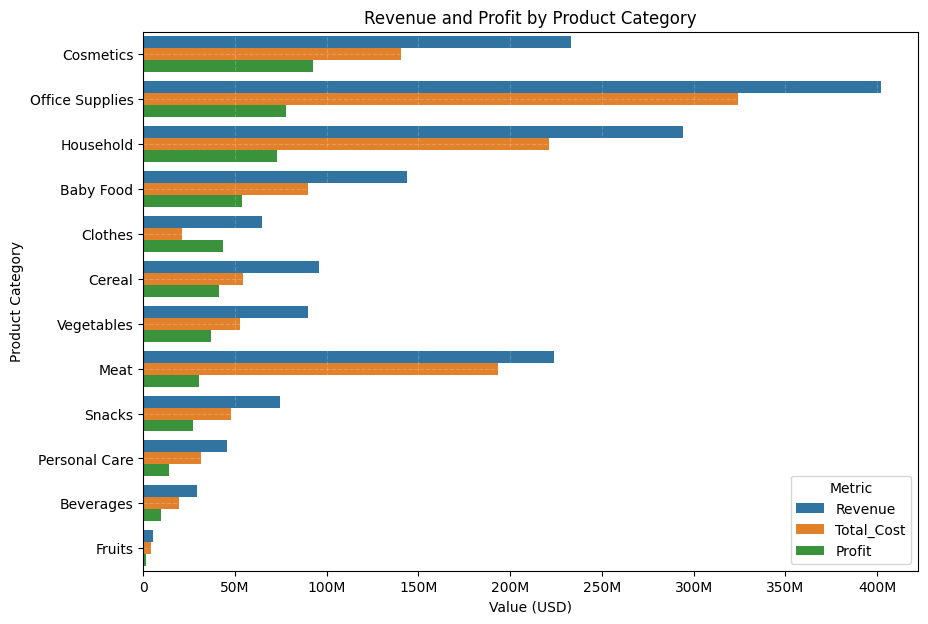

In [ ]:
#@title Gráfico de barras Revenue and Profit x Product Category
plot_data = product_analysis.melt(
    id_vars='Product Category',
    value_vars=['Revenue', 'Total_Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=plot_data,
    y='Product Category',
    x='Value',
    hue='Metric'
)

plt.grid(axis='both', linestyle='--', alpha=0.2, color='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))
plt.title('Revenue and Profit by Product Category')
plt.xlabel('Value (USD)')
plt.ylabel('Product Category')
plt.show()

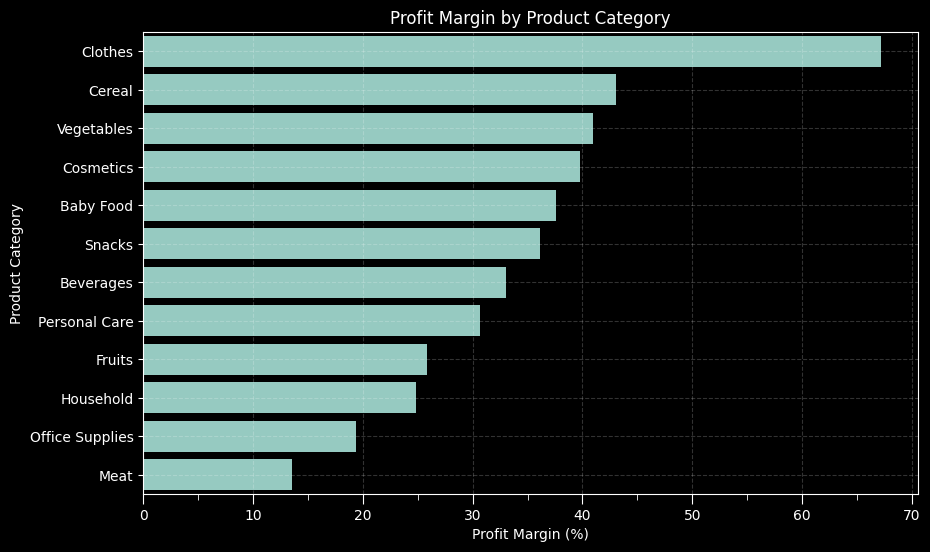

In [ ]:
#@title Gráfico de barras Profit Margin x Product Category
margin_data = product_analysis.sort_values(
    'Profit_Margin',
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=margin_data,
    y='Product Category',
    x='Profit_Margin',
    ax=ax
)

ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='x', which='major', length=7)
ax.tick_params(axis='x', which='minor', length=4)
plt.title('Profit Margin by Product Category')
plt.grid(axis='both', linestyle='--', alpha=0.2, color='white')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Product Category')
plt.show()

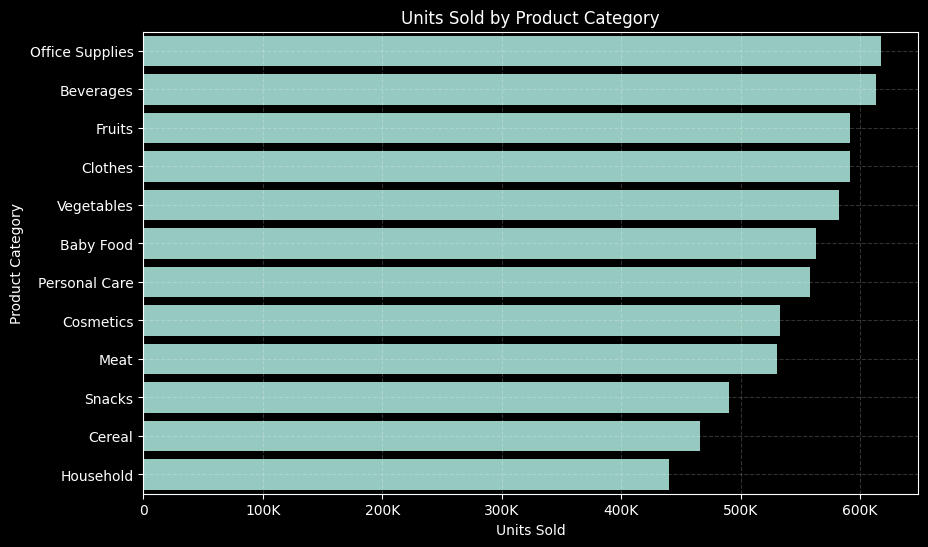

In [ ]:
#@title Gráfico de barras Units Sold x Product Category

units_data = product_analysis.sort_values(
    'Units_Sold',
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=units_data,
    y='Product Category',
    x='Units_Sold',
)

plt.title('Units Sold by Product Category')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))
plt.grid(axis='both', linestyle='--', alpha=0.2, color='white')
plt.xlabel('Units Sold')
plt.ylabel('Product Category')
plt.show()

#### Principais Insights

A análise mostra que diferentes métricas levam a conclusões distintas:

- **Office Supplies** apresenta o maior volume comercial, liderando em receita, pedidos e unidades vendidas.
- **Cosmetics** apresenta o maior lucro absoluto.
- **Clothes** possui a maior margem de lucro, indicando maior rentabilidade proporcional.
- **Meat** apresenta receita elevada, mas margem relativamente baixa.
- **Fruits** possui alto volume de unidades vendidas, mas baixa receita e lucro, indicando menor valor unitário dos produtos.

Esses resultados reforçam que volume de vendas, faturamento e rentabilidade devem ser avaliados de forma complementar.

### 7.2 Análise Geográfica

A análise geográfica avalia o desempenho das vendas em diferentes regiões e países, considerando principalmente receita e lucro.

Para regiões, são comparados os resultados entre as áreas identificadas na base e os registros classificados como `Unknown`.

Para países, como existem muitas categorias, a visualização foi concentrada nos mercados com maior contribuição para o lucro, evitando poluição visual e facilitando a comparação.

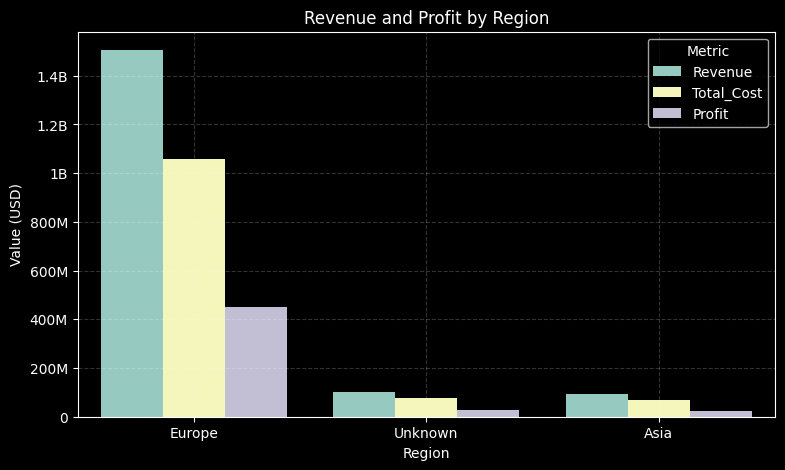

In [ ]:
#@title Gráfico de barras Revenue x Region
region_financial = region_analysis.melt(
    id_vars='Region',
    value_vars=['Revenue', 'Total_Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_financial,
    x='Region',
    y='Value',
    hue='Metric'
)

plt.title('Revenue and Profit by Region')
plt.grid(axis='both', linestyle='--', alpha=0.2, color='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
plt.xlabel('Region')
plt.ylabel('Value (USD)')

plt.show()

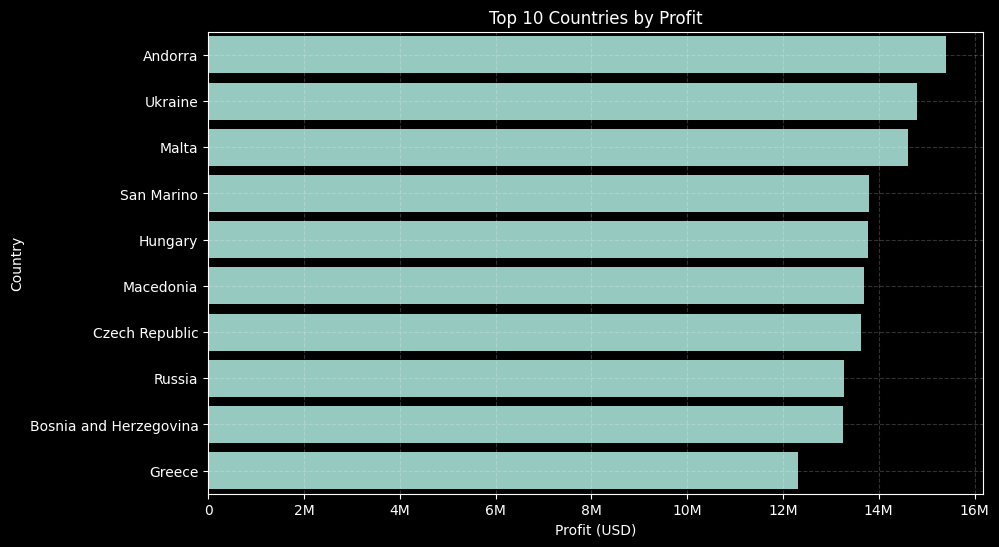

In [ ]:
#@title Gráfico de barras Top 10 Countries by Profit
top_countries_profit = (
    country_analysis
    .sort_values('Profit', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_countries_profit,
    y='Country',
    x='Profit'
)

plt.title('Top 10 Countries by Profit')
plt.grid(axis='both', linestyle='--', alpha=0.2, color='white')
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(FuncFormatter(compact_number))
plt.xlabel('Profit (USD)')
plt.ylabel('Country')

plt.show()

#### Principais Insights

A operação apresenta forte concentração na **Europa**, que reúne a maior parte da receita, do lucro, do volume vendido e da quantidade de pedidos.

A **Ásia** possui participação significativamente menor no desempenho total.

Os registros classificados como `Unknown` representam um volume financeiro relevante, indicando que a ausência de informação geográfica não deve ser ignorada nas análises gerais.

Entre os países identificados, **Andorra** apresentou o maior lucro total, seguida por mercados como **Ukraine** e **Malta**.

### 7.3 Análise por Canal de Vendas

A análise por canal compara o desempenho das vendas realizadas de forma **Online** e **Offline**.

Foram avaliadas métricas financeiras e operacionais, incluindo receita, lucro e volume de unidades vendidas, com o objetivo de identificar diferenças relevantes entre os dois canais.

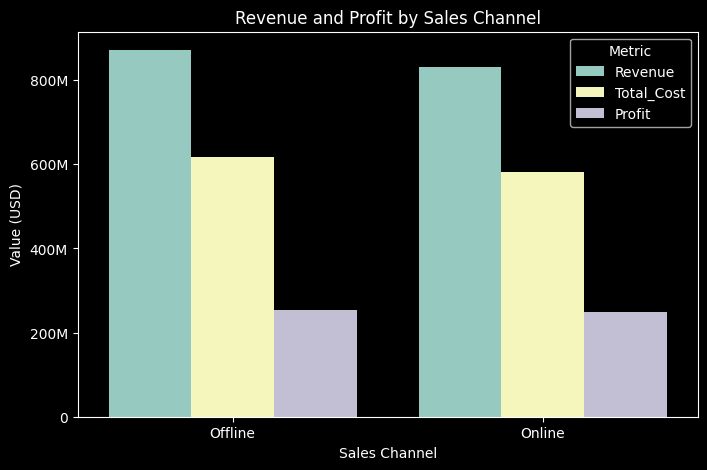

In [ ]:
#@title Gráfico de barras Revenue and Profit by Sales Channel
channel_financial = channel_analysis.melt(
    id_vars='Sales Channel',
    value_vars=['Revenue', 'Total_Cost', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=channel_financial,
    x='Sales Channel',
    y='Value',
    hue='Metric',
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(compact_number))
ax.set_title('Revenue and Profit by Sales Channel')
ax.set_xlabel('Sales Channel')
ax.set_ylabel('Value (USD)')

plt.show()

#### Principais Insights

Os canais **Online** e **Offline** apresentam desempenho bastante semelhante nas métricas analisadas.

Não foram observadas diferenças expressivas em receita, lucro ou volume de unidades vendidas que indiquem uma vantagem clara de um canal sobre o outro.

Dessa forma, o canal de vendas, isoladamente, não parece ser um fator determinante para o desempenho comercial nesta base.

### 7.4 Análise do Tempo de Envio

Nesta etapa é analisado o intervalo entre a data do pedido e a data de envio, utilizando a métrica `Shipping Days`.

O objetivo é identificar possíveis diferenças no tempo médio de envio entre:

- categorias de produtos;
- países;
- regiões.

A análise considera principalmente a média e a mediana do tempo de envio, buscando identificar grupos com maior ou menor eficiência logística.

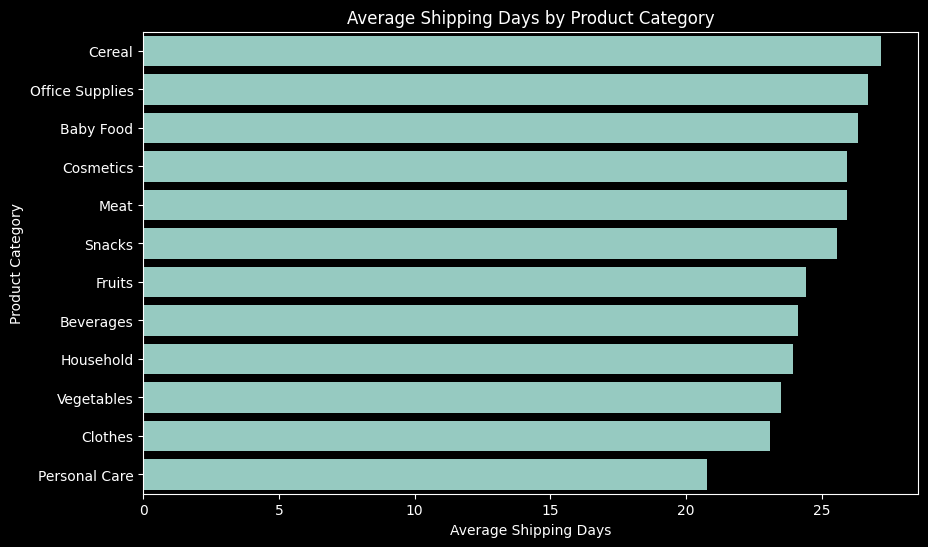

In [ ]:
#@title Gráfico de barras Average Shipping Days by Product Category

shipping_product_plot = shipping_product_analysis.sort_values(
    'Avg_Shipping_Days',
    ascending=False
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=shipping_product_plot,
    y='Product Category',
    x='Avg_Shipping_Days',
    ax=ax
)

ax.set_title('Average Shipping Days by Product Category')
ax.set_xlabel('Average Shipping Days')
ax.set_ylabel('Product Category')

plt.show()

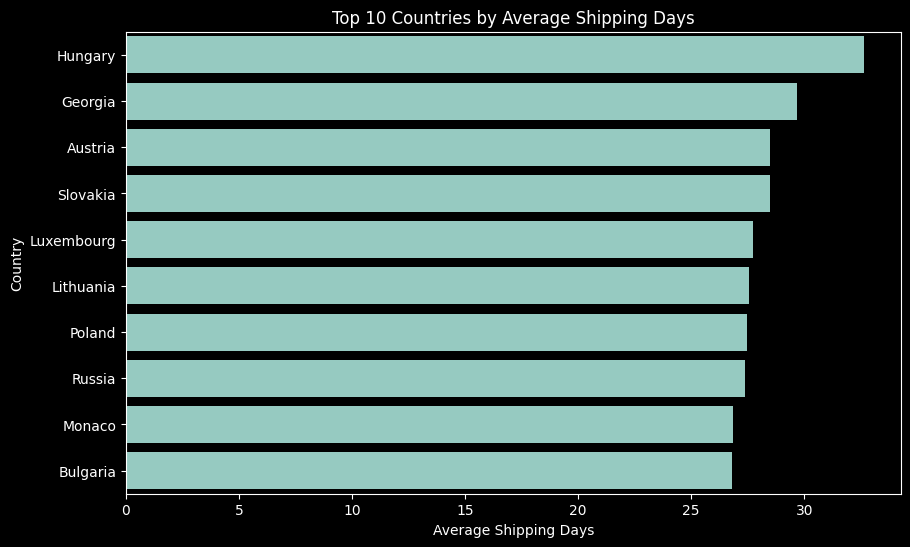

In [ ]:
#@title Gráfico de barras Top 10 Countries by Average Shipping Days

top_shipping_countries = (
    shipping_country_analysis
    .sort_values('Avg_Shipping_Days', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_shipping_countries,
    y='Country',
    x='Avg_Shipping_Days',
    ax=ax
)

ax.set_title('Top 10 Countries by Average Shipping Days')
ax.set_xlabel('Average Shipping Days')
ax.set_ylabel('Country')

plt.show()

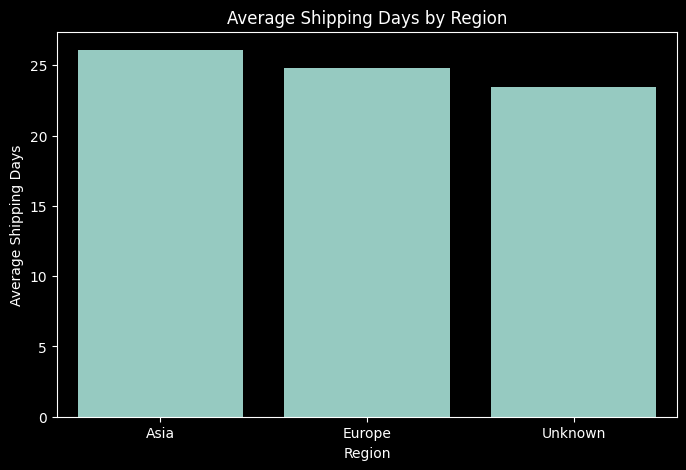

In [ ]:
#@title Gráfico de barras Average Shipping Days by Region

shipping_region_plot = (
    shipping_region_analysis
    .sort_values('Avg_Shipping_Days', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=shipping_region_plot,
    x='Region',
    y='Avg_Shipping_Days',
    ax=ax
)

ax.set_title('Average Shipping Days by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Average Shipping Days')

plt.show()

#### Principais Insights

A análise do tempo de envio mostra diferenças entre categorias de produtos, países e regiões, embora a variação geral não seja muito elevada.

- Entre as **categorias de produtos**, `Cereal` apresenta o maior tempo médio de envio, próximo de 27 dias, enquanto `Personal Care` possui o menor, em torno de 21 dias. A maioria das categorias permanece concentrada aproximadamente entre 23 e 27 dias.
- Entre os **países com maior tempo médio de envio**, `Hungary` se destaca com aproximadamente 33 dias, seguida por `Georgia`, `Austria` e `Slovakia`, próximas de 29–30 dias.
- Na análise por **região**, a `Asia` apresenta o maior tempo médio de envio, em torno de 26 dias, seguida pela `Europe`, próxima de 25 dias. Os registros com região `Unknown` apresentam média inferior, próxima de 23 dias.

De modo geral, as diferenças observadas sugerem alguma variação logística entre produtos e localidades, mas não indicam, isoladamente, discrepâncias extremamente elevadas no tempo de envio.

### 7.5 Relação entre Tempo de Envio e Lucro

Para investigar se o tempo necessário para o envio está relacionado ao resultado financeiro dos pedidos, foi analisada a relação entre `Shipping Days` e `Profit`.

A análise combina:

- um gráfico de dispersão para observar visualmente o comportamento das duas variáveis;
- uma linha de tendência linear;
- o coeficiente de correlação de Pearson para quantificar a intensidade da associação linear.

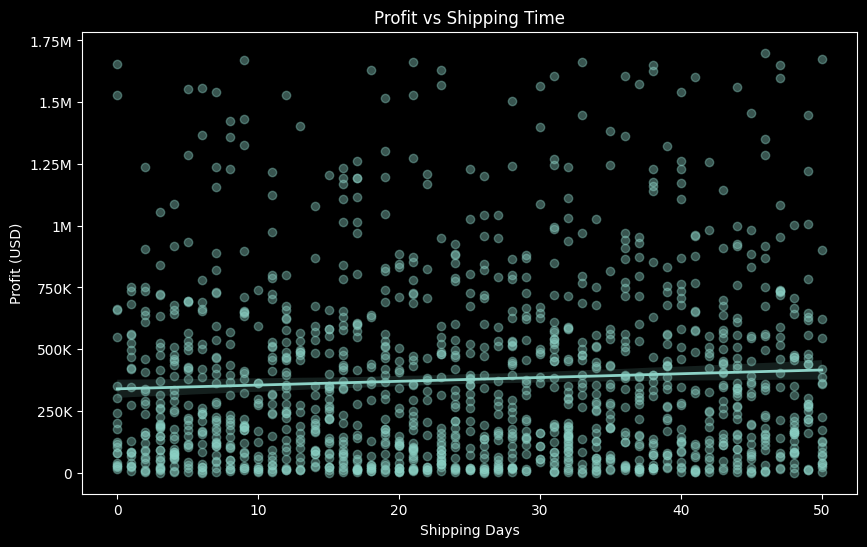

Correlation: 0.060


In [ ]:
#@title Scatter Plot Profit x Shipping Time

fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Shipping Days',
    y='Profit',
    scatter_kws={'alpha': 0.4},
    line_kws={'linewidth': 2},
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(compact_number))

ax.set_title('Profit vs Shipping Time')
ax.set_xlabel('Shipping Days')
ax.set_ylabel('Profit (USD)')

plt.show()

shipping_profit_corr = df['Shipping Days'].corr(df['Profit'])

print(f'Correlation: {shipping_profit_corr:.3f}')

#### Principais Insights

O gráfico apresenta grande dispersão dos valores de lucro ao longo de praticamente todo o intervalo de tempo de envio.

A correlação de **0,060** indica uma associação linear positiva extremamente fraca entre `Shipping Days` e `Profit`.

Dessa forma, **não foi identificada uma relação linear relevante entre o tempo de envio e o lucro dos pedidos** nesta base. Isso sugere que outros fatores possuem influência significativamente maior sobre o resultado financeiro.

É importante destacar que essa análise identifica associação, e não causalidade.

### 7.6 Dinâmica das Vendas ao Longo do Tempo

Nesta etapa é analisada a evolução da receita ao longo do tempo, com agregação mensal.

A análise temporal é realizada por:

- categorias de produtos;
- países;
- regiões.

Como algumas dimensões possuem muitas categorias, as visualizações de produtos e países foram limitadas aos grupos de maior receita total, reduzindo a poluição visual e facilitando a identificação de tendências.

O objetivo é observar possíveis padrões de crescimento, queda, volatilidade e concentração das vendas ao longo do período analisado.

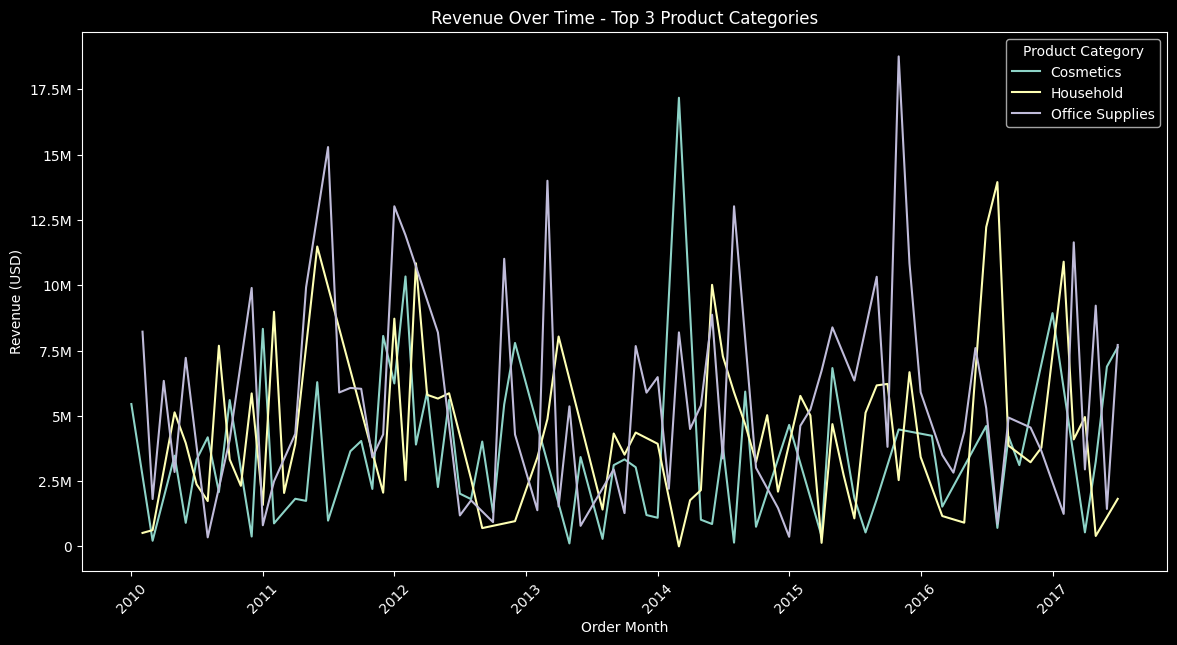

In [ ]:
top_3_products = (
    product_analysis
    .sort_values('Revenue', ascending=False)
    .head(3)['Product Category']
)

monthly_product_top3 = monthly_product_analysis[
    monthly_product_analysis['Product Category'].isin(top_3_products)
]

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=monthly_product_top3,
    x='Order Month',
    y='Revenue',
    hue='Product Category',
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(compact_number))

ax.set_title('Revenue Over Time - Top 3 Product Categories')
ax.set_xlabel('Order Month')
ax.set_ylabel('Revenue (USD)')

plt.xticks(rotation=45)
plt.show()

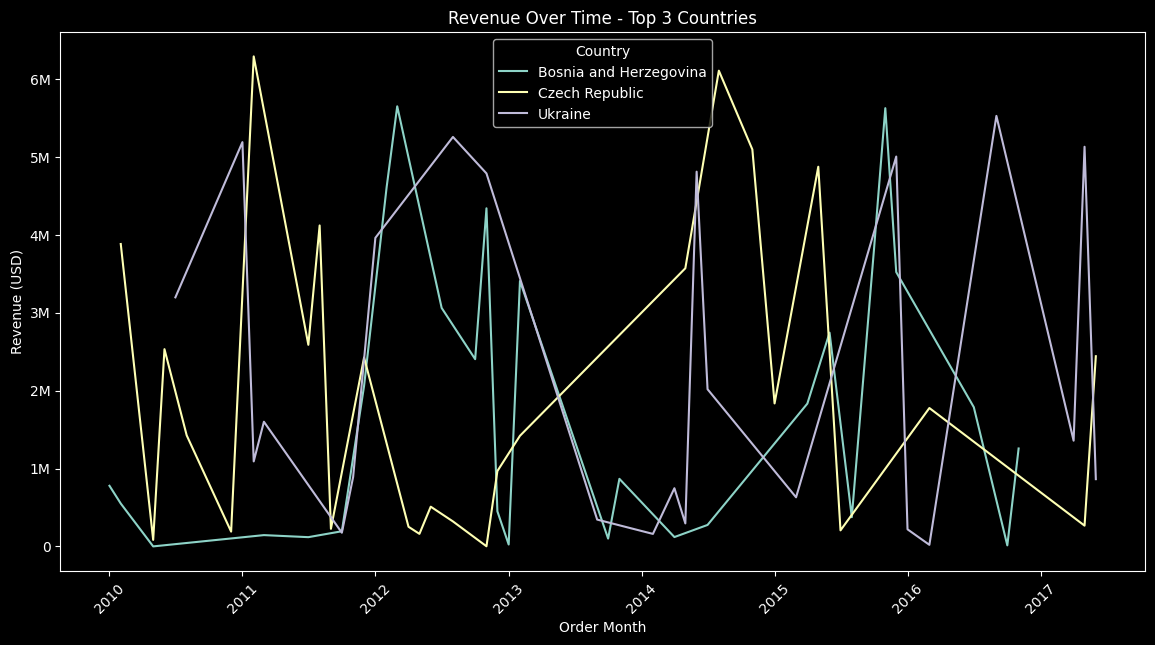

In [ ]:
#@title Gráfico de Linha Revenue ao decorrer do tempo por Country

top_3_countries = (
    country_analysis
    .sort_values('Revenue', ascending=False)
    .head(3)['Country']
)

monthly_country_top3 = monthly_country_analysis[
    monthly_country_analysis['Country'].isin(top_3_countries)
]

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=monthly_country_top3,
    x='Order Month',
    y='Revenue',
    hue='Country',
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(compact_number))

ax.set_title('Revenue Over Time - Top 3 Countries')
ax.set_xlabel('Order Month')
ax.set_ylabel('Revenue (USD)')

plt.xticks(rotation=45)
plt.show()

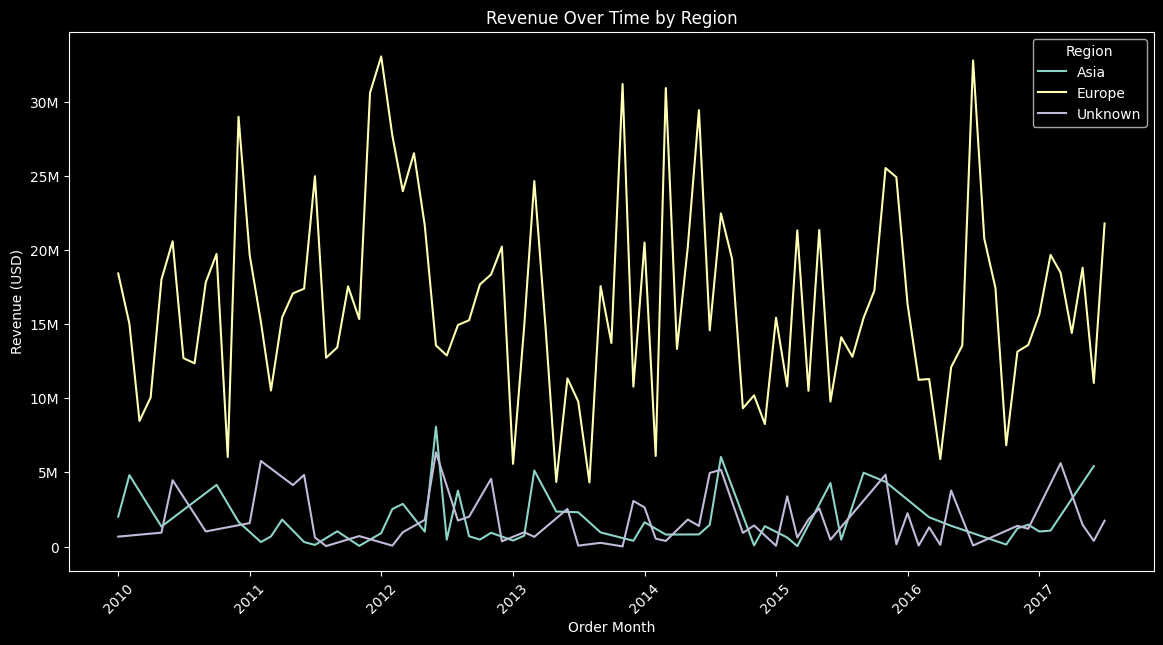

In [ ]:
#@title Gráfico de Linha Revenue ao decorrer do tempo por Region

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=monthly_region_analysis,
    x='Order Month',
    y='Revenue',
    hue='Region',
    ax=ax
)

ax.yaxis.set_major_formatter(FuncFormatter(compact_number))

ax.set_title('Revenue Over Time by Region')
ax.set_xlabel('Order Month')
ax.set_ylabel('Revenue (USD)')

plt.xticks(rotation=45)
plt.show()

#### Principais Insights

A análise temporal revela um comportamento bastante **volátil**, com oscilações relevantes de receita ao longo do período e sem uma tendência consistente de crescimento ou queda.

- Entre as **categorias de produtos**, `Office Supplies` apresenta alguns dos maiores picos de receita, enquanto `Cosmetics` e `Household` também registram períodos de forte crescimento pontual. Nenhuma das três categorias demonstra uma trajetória contínua de crescimento ao longo de toda a série.
- Entre os **países analisados**, `Bosnia and Herzegovina`, `Czech Republic` e `Ukraine` apresentam elevada variação de receita, alternando períodos de maior atividade com períodos de baixo volume. Não há um país que mantenha liderança consistente durante todo o período.
- Na análise por **região**, a `Europe` mantém uma receita significativamente superior às demais regiões durante praticamente toda a série temporal, reforçando a forte concentração geográfica das vendas identificada anteriormente.
- Apesar dessa liderança, a receita europeia também apresenta grande volatilidade, com diversos picos e quedas ao longo do período.
- `Asia` e os registros classificados como `Unknown` permanecem em patamares muito inferiores à Europa, embora também apresentem oscilações e alguns picos pontuais.

De forma geral, os resultados indicam **alta variabilidade das vendas ao longo do tempo**, com predominância da Europa e ausência de uma tendência sustentada de crescimento ou redução nas dimensões analisadas.

### 7.7 Vendas por Dia da Semana e Sazonalidade

Para investigar possíveis padrões semanais de consumo, as vendas foram analisadas por categoria de produto e dia da semana.

Primeiro, foi calculada a média de unidades vendidas para cada combinação entre produto e dia da semana. Em seguida, foi analisada a participação percentual de cada dia no volume total vendido de cada categoria.

Essa abordagem permite identificar produtos cujas vendas apresentam maior concentração em determinados dias e avaliar possíveis indícios de sazonalidade semanal.

Seasonality Analysis:
   Product Category Order Day      Share
28        Cosmetics    Friday  26.538231
43        Household    Monday  24.492730
38           Fruits    Sunday  22.943455
71           Snacks    Monday  22.016484
26          Clothes   Tuesday  21.008649
16           Cereal  Saturday  20.672558
80       Vegetables    Sunday  19.569166
50             Meat    Monday  18.927561
67    Personal Care  Thursday  17.155061
56  Office Supplies    Friday  17.143940
9         Beverages  Saturday  16.738620
3         Baby Food    Sunday  16.653990

Seasonality Strength Analysis:
                  Max_Share  Min_Share     Spread
Product Category                                 
Household         24.492730   4.650550  19.842180
Cosmetics         26.538231   9.398809  17.139423
Fruits            22.943455   7.232047  15.711408
Snacks            22.016484   8.244859  13.771626
Clothes           21.008649   7.362040  13.646609
Cereal            20.672558   8.948968  11.723590
Vegetables   

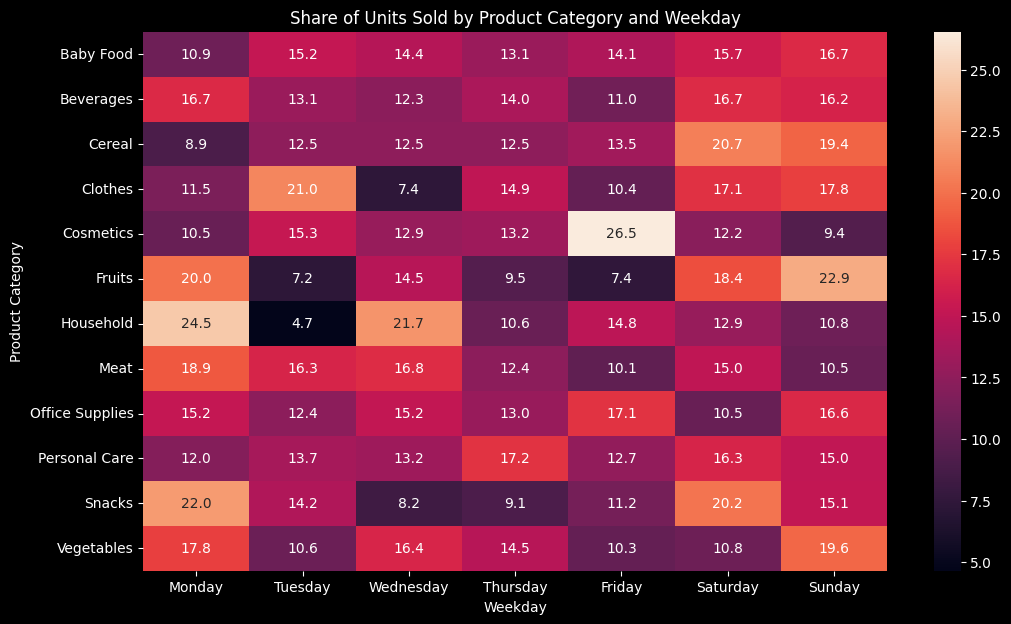

In [ ]:
#@title Gráfico Heatmap Média de Units Sold por Product Category e Weekday
weekday_sales = (
    df.groupby(
        ['Product Category', 'Order Day'],
        as_index=False
    )
    .agg(
        Units_Sold=('Units Sold', 'sum')
    )
)

weekday_sales['Share'] = (
    weekday_sales['Units_Sold']
    / weekday_sales.groupby('Product Category')['Units_Sold'].transform('sum')
    * 100
)

seasonality_analysis = (
    weekday_sales.loc[
        weekday_sales.groupby('Product Category')['Share'].idxmax()
    ]
    [['Product Category', 'Order Day', 'Share']]
    .sort_values('Share', ascending=False)
)

seasonality_strength = (
    weekday_sales
    .groupby('Product Category')
    .agg(
        Max_Share=('Share', 'max'),
        Min_Share=('Share', 'min')
    )
)

seasonality_strength['Spread'] = (
    seasonality_strength['Max_Share']
    - seasonality_strength['Min_Share']
)

seasonality_strength = seasonality_strength.sort_values(
    'Spread',
    ascending=False
)

print('Seasonality Analysis:')
print(seasonality_analysis)

print('\nSeasonality Strength Analysis:')
print(seasonality_strength)

daily_product_sales = (
    df.groupby(
        ['Order Date', 'Order Day', 'Product Category'],
        as_index=False
    )
    .agg(
        Units_Sold=('Units Sold', 'sum')
    )
)

weekday_avg_sales = (
    daily_product_sales
    .groupby(
        ['Order Day', 'Product Category'],
        as_index=False
    )
    .agg(
        Avg_Units_Sold=('Units_Sold', 'mean')
    )
)

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_avg_sales['Order Day'] = pd.Categorical(
    weekday_avg_sales['Order Day'],
    categories=day_order,
    ordered=True
)

weekday_heatmap = weekday_avg_sales.pivot(
    index='Product Category',
    columns='Order Day',
    values='Avg_Units_Sold'
)

weekday_share_heatmap = weekday_sales.pivot(
    index='Product Category',
    columns='Order Day',
    values='Share'
)[day_order]



plt.figure(figsize=(12, 7))

sns.heatmap(
    weekday_share_heatmap,
    annot=True,
    fmt='.1f'
)

plt.title('Share of Units Sold by Product Category and Weekday')
plt.xlabel('Weekday')
plt.ylabel('Product Category')
plt.show()

####A análise por dia da semana mostra que algumas categorias apresentam padrões de concentração relevantes. Household apresentou a maior variação entre o melhor e o pior dia da semana, seguido por Cosmetics e Fruits. Cosmetics, por exemplo, concentrou aproximadamente 26,5% das unidades vendidas às sextas-feiras, enquanto Household apresentou cerca de 24,5% das vendas às segundas-feiras. Esses resultados sugerem a existência de padrões sazonais semanais para algumas categorias, embora sejam necessárias séries temporais mais longas e análises adicionais para afirmar sazonalidade de forma mais ampla

#### Principais Insights

A análise mostra que algumas categorias apresentam diferenças relevantes na distribuição das vendas ao longo da semana.

- **Cosmetics** apresenta a maior concentração em um único dia, com aproximadamente **26,5%** das unidades vendidas às sextas-feiras.
- **Household** concentra cerca de **24,5%** das vendas às segundas-feiras e apresenta a maior diferença entre o melhor e o pior dia da semana, com um spread de aproximadamente **19,8 pontos percentuais**.
- **Fruits** apresenta aproximadamente **22,9%** das vendas aos domingos.
- **Snacks**, **Clothes** e **Cereal** também apresentam concentrações superiores a 20% em seus dias de maior volume.
- Categorias como **Personal Care**, **Beverages** e **Baby Food** apresentam distribuição mais uniforme durante a semana.

Os resultados indicam **indícios de sazonalidade semanal** para algumas categorias, principalmente `Household`, `Cosmetics` e `Fruits`.

Entretanto, esses padrões não são suficientes para afirmar sazonalidade de longo prazo. Uma análise mais ampla exigiria avaliar padrões recorrentes entre meses, estações ou anos.

## 8. Principais Insights e Conclusões de Negócio

A análise permitiu identificar diferentes padrões de desempenho comercial, financeiro e operacional ao longo da base de vendas.

### Desempenho por Produto

- `Office Supplies` apresenta o maior volume comercial, liderando em receita, número de pedidos e unidades vendidas.
- `Cosmetics` apresenta o maior lucro absoluto.
- `Clothes` possui a maior margem de lucro, indicando maior rentabilidade proporcional.
- `Meat` apresenta receita elevada, mas margem relativamente baixa.
- Os resultados mostram que volume de vendas, receita e rentabilidade devem ser analisados de forma complementar.

### Desempenho Geográfico

- A operação apresenta forte concentração na `Europe`, responsável pela maior parte da receita, lucro, volume vendido e quantidade de pedidos.
- A `Asia` apresenta participação significativamente menor.
- Os registros com localização `Unknown` representam volume financeiro relevante, indicando uma oportunidade de melhoria na qualidade dos dados geográficos.
- Entre os países identificados, `Andorra` apresentou o maior lucro total.

### Canais de Venda

- Os canais `Online` e `Offline` apresentam resultados semelhantes nas principais métricas analisadas.
- Não foi identificada uma vantagem clara de um canal sobre o outro em receita, lucro ou volume vendido.

### Logística

- O tempo médio de envio apresenta alguma variação entre produtos, países e regiões.
- `Cereal` apresenta um dos maiores tempos médios de envio entre as categorias, enquanto `Personal Care` apresenta um dos menores.
- Entre os países analisados, `Hungary` apresenta o maior tempo médio de envio.
- A `Asia` possui tempo médio de envio ligeiramente superior ao da `Europe`.

### Tempo de Envio e Lucro

A correlação entre `Shipping Days` e `Profit` foi de aproximadamente **0,060**, indicando uma associação linear praticamente inexistente.

Dessa forma, não foi encontrada evidência de que o tempo de envio esteja linearmente relacionado ao lucro dos pedidos nesta base.

### Evolução das Vendas

- As vendas apresentam alta volatilidade ao longo do período analisado.
- Não foi identificada uma tendência consistente de crescimento ou redução nas principais categorias e países.
- A `Europe` permanece como a principal região em receita durante praticamente toda a série temporal.

### Padrões Semanais

Algumas categorias apresentam concentração relevante de vendas em determinados dias da semana.

`Household`, `Cosmetics` e `Fruits` apresentam alguns dos maiores contrastes entre os dias de maior e menor volume, indicando possíveis padrões sazonais semanais.

Esses resultados, entretanto, não são suficientes para afirmar a existência de sazonalidade de longo prazo.

## 9. Limitações da Análise

Apesar de permitir uma visão ampla do desempenho das vendas, a análise possui algumas limitações que devem ser consideradas na interpretação dos resultados.

- **Dados geográficos ausentes:** 82 pedidos não possuem `Country Code`. Esses registros foram preservados e classificados como `Unknown`, mas não podem ser atribuídos corretamente a um país ou região.

- **Registros sem quantidade vendida:** 2 pedidos sem `Units Sold` foram removidos da base analítica, pois não seria possível calcular receita, custo e lucro sem realizar uma imputação artificial.

- **Definição de lucro:** a métrica `Profit` foi calculada como `Revenue - Total Cost`, considerando apenas o custo dos produtos disponível na base. Portanto, não representa o lucro líquido contábil da operação, pois não inclui despesas como logística, impostos, marketing ou custos administrativos.

- **Séries temporais esparsas:** algumas categorias e países não apresentam vendas registradas em todos os meses. Dessa forma, os gráficos de linha devem ser interpretados como uma representação dos períodos com observações disponíveis, e não necessariamente como uma série contínua.

- **Sazonalidade:** foram identificados padrões de concentração das vendas em determinados dias da semana. Esses resultados indicam possível sazonalidade semanal, mas não são suficientes para comprovar padrões sazonais mensais ou anuais.

- **Correlação e causalidade:** a análise da relação entre tempo de envio e lucro avalia associação linear. Uma correlação baixa não comprova ausência de efeito causal e outros fatores não disponíveis na base podem influenciar o lucro.